# Whakaari Cause-Trigger Analysis

This notebook applies the Cause-Trigger workflow to the Whakaari 2019 eruption case study. The full dataset is loaded as the constructed data product, but the algorithm is run only on a fixed case-study interval around the eruption.

The split into \(I_1\) and \(I_2\) is selected automatically from the effect variable. The known eruption time is shown only for physical interpretation.

## 1. Imports, paths, and case-study interval

In [5]:
from pathlib import Path
import sys
import warnings
import pandas as pd

warnings.filterwarnings("ignore", message="No frequency information was provided")
warnings.filterwarnings("ignore", message="A date index has been provided")
warnings.filterwarnings("ignore", message="invalid value encountered")
warnings.filterwarnings("ignore", message="An input array is constant")

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 40)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import (
    COMPACT_RUN_SPECS,
    DEFAULT_RUN_SPECS,
    EFFECT,
    WhakaariWorkflowConfig,
    case_study_interval,
    compact_grid_errors,
    compact_grid_outputs,
    expand_pair_outputs,
    load_model_frame,
    model_overview,
    plot_effect_with_split,
    reference_parameter_table,
    run_sensitivity_grid,
    split_diagnostics,
)

WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"
EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")

In [ ]:
CASE_PRE_DAYS = 14
CASE_POST_HOURS = 72
MIN_I1_LENGTH = 168
MIN_I2_LENGTH = 72
MAX_LAGS = 12
run_specs = COMPACT_RUN_SPECS # "DEFAULT_RUN_SPECS" or "COMPACT_RUN_SPECS". compact considers tau=0 contemporaneous trigger candidates
cond_ind_test = "parcorr" # "parcorr" or "robust_parcorr"
pcmci_pc_alpha= 0.10, # significance level for PCMCI PC algorithm conditional independence tests. Default is 0.05.
pcmci_alpha_level= 0.05, # significance level for PCMCI conditional independence tests. Default is 0.05.
pcmci_fdr_method= None, # "fdr_bh" or None. If None, no FDR correction is applied to the PCMCI results.


X_full = load_model_frame(WHAKAARI_PATH)
X = case_study_interval(
    X_full,
    EVENT_TIME,
    pre_days=CASE_PRE_DAYS,
    post_hours=CASE_POST_HOURS,
)

display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,408,7,2019-11-25 02:00:00+00:00,2019-12-12 01:00:00+00:00,h,effect_tremor_5_15_scaled,-0.311013,-0.244216,0.123805,6.570928,0.499994,0.309964,240


## 2. Reference parameters and split audit

This section reports two checks before running the causal backends.

`reference_parameters` shows the VAR-AIC and VAR-BIC lag suggestions. These are metadata only; they do not select the final interpretation.

`split_diagnostics` shows the automatic Cause-Trigger split: `split_time`, lengths of \(I_1\) and \(I_2\), the target mean change, distance to the known event time, and whether the split is a boundary artefact.

,effect,selected_lag,selected_distribution,lag_method,max_lags,fallback_lag,fallback_distribution
0,effect_tremor_5_15_scaled,4,gaussian,VAR-AIC,12,1,gaussian
1,effect_tremor_5_15_scaled,2,gaussian,VAR-BIC,12,1,gaussian


,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split,split_end_index,split_end_time,split_score,signed_mean_I1,signed_mean_I2
0,effect_tremor_5_15_scaled,335,2019-12-09 01:00:00+00:00,335,73,0.111478,1.203529,1.09205,2019-12-09 01:11:00+00:00,-1 days +23:49:00,False,408,2019-12-12 01:00:00+00:00,1.09205,-0.111478,1.203529


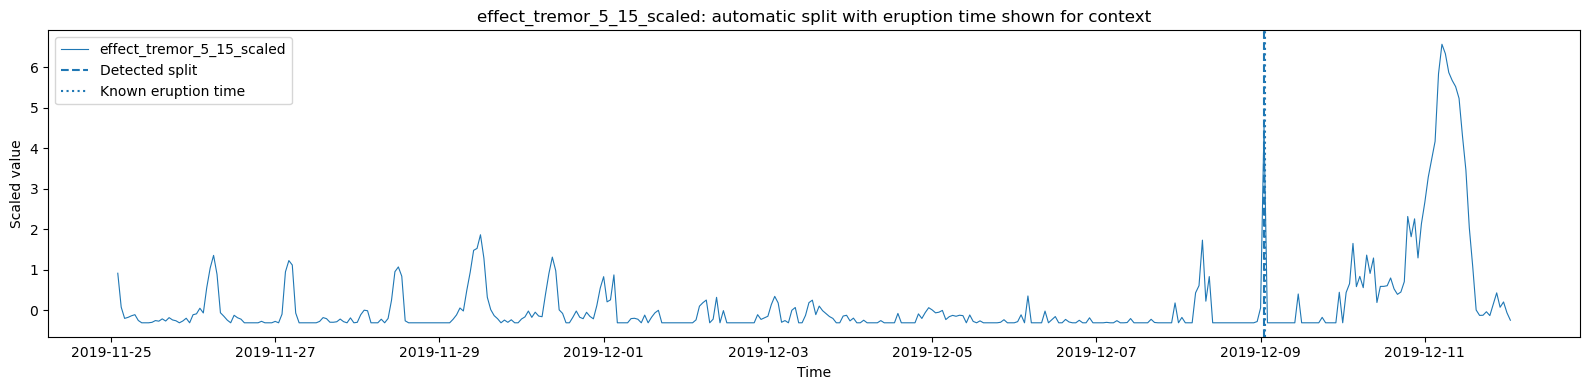

In [ ]:
reference_parameters = reference_parameter_table(
    X,
    EFFECT,
    max_lags=MAX_LAGS,
    fallback_lag=1,
    fallback_distribution="gaussian",
)
display(reference_parameters)

selected_lag = int(reference_parameters.loc[
    reference_parameters["lag_method"].eq("VAR-AIC"),
    "selected_lag"
].iloc[0])

workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    selected_lag=selected_lag,
    max_lags=MAX_LAGS,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    distribution="gaussian",
    parameter_source="reference_metadata",
    pcmci_pc_alpha=pcmci_pc_alpha,
    pcmci_alpha_level=pcmci_alpha_level,
    pcmci_fdr_method=pcmci_fdr_method,
    run_specs=run_specs,
)

split_row = split_diagnostics(
    X,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([split_row]))

plot_effect_with_split(
    X,
    EFFECT,
    split_row,
    event_time=EVENT_TIME,
)

## 3. Backend and lag grid

This section runs HMML, PCMCI, and PCMCI+ over max_lags.

The first table expands accepted cause-trigger pairs into one row per pair. The second table keeps rows with any backend signal: non-empty \(B_2\), trigger candidates, accepted triggers, accepted pairs, or PCMCI+ contemporaneous links.

Main columns: `B_2` = selected lagged parents of the effect; `trigger_candidates` = variables eligible for moderation testing; `accepted_triggers` = candidates passing the F-test; `pairs` = final cause-trigger pairs.

In [8]:
grid_all = run_sensitivity_grid(
    X,
    workflow,
    run_specs=run_specs,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test=cond_ind_test,
)

pair_rows = expand_pair_outputs(grid_all)
signal_rows = compact_grid_outputs(grid_all, mode="signals")
error_rows = compact_grid_errors(grid_all)

print(f"All grid rows: {len(grid_all)}")
print(f"Rows with accepted pairs: {len(pair_rows)}")
print(f"Rows with any backend signal: {len(signal_rows)}")
print(f"Rows with backend errors: {len(error_rows)}")

display(pair_rows)
display(signal_rows)

if not error_rows.empty:
    display(error_rows)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:898: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(resid / self.family.variance(mu)) / self.df_resid
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
c:\Users\ces

All grid rows: 36
Rows with accepted pairs: 23
Rows with any backend signal: 29
Rows with backend errors: 0


,backend,run,lag,distribution,cause,trigger,split_timestamp,I1_length,I2_length,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links
0,hmml,hmml_backend_beta,1,gaussian,GNSS_deformation_scaled,event_rate_2_5_scaled,2019-12-09 01:00:00+00:00,335,73,2.220446e-16,0.627254,0
1,hmml,hmml_backend_beta,1,gaussian,GNSS_deformation_scaled,rain_12h_sum_scaled,2019-12-09 01:00:00+00:00,335,73,2.220446e-16,0.627254,0
2,hmml,hmml_backend_beta,7,gaussian,GNSS_deformation_scaled,rain_12h_sum_scaled,2019-12-09 01:00:00+00:00,335,73,2.562739e-02,0.076596,0
3,hmml,hmml_backend_beta,8,gaussian,ratio_4p5_8_over_8_16_scaled,rain_12h_sum_scaled,2019-12-09 01:00:00+00:00,335,73,2.886580e-15,0.636965,0
4,hmml,hmml_backend_beta,9,gaussian,ratio_4p5_8_over_8_16_scaled,hydro_2_5_scaled,2019-12-09 01:00:00+00:00,335,73,2.537002e-05,0.254051,0
5,hmml,hmml_backend_beta,9,gaussian,ratio_4p5_8_over_8_16_scaled,event_rate_2_5_scaled,2019-12-09 01:00:00+00:00,335,73,2.537002e-05,0.254051,0
6,hmml,hmml_backend_beta,9,gaussian,ratio_4p5_8_over_8_16_scaled,rain_12h_sum_scaled,2019-12-09 01:00:00+00:00,335,73,2.537002e-05,0.254051,0
7,hmml,hmml_backend_beta,10,gaussian,ratio_4p5_8_over_8_16_scaled,hydro_2_5_scaled,2019-12-09 01:00:00+00:00,335,73,1.332268e-15,0.658083,0
8,hmml,hmml_backend_beta,10,gaussian,ratio_4p5_8_over_8_16_scaled,rain_12h_sum_scaled,2019-12-09 01:00:00+00:00,335,73,1.332268e-15,0.658083,0
9,hmml,hmml_backend_beta,11,gaussian,ratio_4p5_8_over_8_16_scaled,hydro_2_5_scaled,2019-12-09 01:00:00+00:00,335,73,1.082046e-11,0.545624,0


,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,min_p_value,max_rss_reduction_ratio,n_contemporaneous_links,error
0,hmml_backend_beta,hmml,1,gaussian,2019-12-09 01:00:00+00:00,335,73,"[event_rate_2_5_scaled, rain_12h_sum_scaled, GNSS_deformation_scaled]","[event_rate_2_5_scaled, rain_12h_sum_scaled]","[event_rate_2_5_scaled, rain_12h_sum_scaled]",[],"[event_rate_2_5_scaled, rain_12h_sum_scaled]",[GNSS_deformation_scaled],"[(GNSS_deformation_scaled, event_rate_2_5_scaled), (GNSS_deformation_scaled, rain_12h_sum_scaled)]",2.220446e-16,0.627254,0,None
1,hmml_backend_beta,hmml,7,gaussian,2019-12-09 01:00:00+00:00,335,73,"[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled]",[],[rain_12h_sum_scaled],[GNSS_deformation_scaled],"[(GNSS_deformation_scaled, rain_12h_sum_scaled)]",2.562739e-02,0.076596,0,None
2,hmml_backend_beta,hmml,8,gaussian,2019-12-09 01:00:00+00:00,335,73,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, GNSS_deformation_scaled]","[event_rate_2_5_scaled, rain_12h_sum_scaled]","[event_rate_2_5_scaled, rain_12h_sum_scaled]",[],[rain_12h_sum_scaled],[ratio_4p5_8_over_8_16_scaled],"[(ratio_4p5_8_over_8_16_scaled, rain_12h_sum_scaled)]",2.886580e-15,0.636965,0,None
3,hmml_backend_beta,hmml,9,gaussian,2019-12-09 01:00:00+00:00,335,73,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled]",[],"[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]",[ratio_4p5_8_over_8_16_scaled],"[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled), (ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled), (ratio_4p5_8_over_8_16_scaled,...",2.537002e-05,0.254051,0,None
4,hmml_backend_beta,hmml,10,gaussian,2019-12-09 01:00:00+00:00,335,73,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, rain_12h_sum_scaled, pressure_drop_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled]","[hydro_2_5_scaled, rain_12h_sum_scaled, pressure_drop_scaled]",[],"[hydro_2_5_scaled, rain_12h_sum_scaled]",[ratio_4p5_8_over_8_16_scaled],"[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled), (ratio_4p5_8_over_8_16_scaled, rain_12h_sum_scaled)]",1.332268e-15,0.658083,0,None
5,hmml_backend_beta,hmml,11,gaussian,2019-12-09 01:00:00+00:00,335,73,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]",[],"[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]",[ratio_4p5_8_over_8_16_scaled],"[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled), (ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled), (ratio_4p5_8_over_8_16_scaled,...",1.082046e-11,0.545624,0,None
6,hmml_backend_beta,hmml,12,gaussian,2019-12-09 01:00:00+00:00,335,73,"[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled, GNSS_deformation_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]","[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]",[],"[hydro_2_5_scaled, event_rate_2_5_scaled, rain_12h_sum_scaled]",[GNSS_deformation_scaled],"[(GNSS_deformation_scaled, hydro_2_5_scaled), (GNSS_deformation_scaled, event_rate_2_5_scaled), (GNSS_deformation_scaled, rain_12h_sum_s...",2.220446e-16,0.691533,0,None
7,pcmci_ridge,pcmci,3,gaussian,2019-12-09 01:00:00+00:00,335,73,[hydro_2_5_scaled],[hydro_2_5_scaled],[h